In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline

In [3]:
df = pd.read_csv("perfect_final_crop_dataset.csv")

print(df.head())
print(df["crop"].unique())

        state  season  crop  plot_area  avg_temp  total_rainfall  humidity  \
0  tamil nadu    rabi  rice       1.23     27.86         1449.67     68.12   
1   karnataka  summer  rice       1.36     28.02         1476.74     69.66   
2   telangana    rabi  rice       1.69     29.12         1197.33     81.66   
3   telangana  kharif  rice       3.99     27.09         1329.55     81.89   
4  tamil nadu  summer  rice       1.46     28.89         1458.21     72.17   

   drought_index soil_type soil_texture  soil_ph  soil_organic_carbon  \
0           0.28  laterite        silty     7.04                 0.66   
1           0.17  laterite        silty     6.74                 0.99   
2           0.14  alluvial        sandy     6.47                 0.84   
3           0.24  laterite        silty     6.65                 0.98   
4           0.24  laterite        silty     7.04                 0.63   

   fertilizer_n  fertilizer_p  fertilizer_k previous_crop  year  ndvi_mean  \
0        145.7

In [5]:
print(df.head())
print(df["crop"].unique())

        state  season  crop  plot_area  avg_temp  total_rainfall  humidity  \
0  tamil nadu    rabi  rice       1.23     27.86         1449.67     68.12   
1   karnataka  summer  rice       1.36     28.02         1476.74     69.66   
2   telangana    rabi  rice       1.69     29.12         1197.33     81.66   
3   telangana  kharif  rice       3.99     27.09         1329.55     81.89   
4  tamil nadu  summer  rice       1.46     28.89         1458.21     72.17   

   drought_index soil_type soil_texture  soil_ph  soil_organic_carbon  \
0           0.28  laterite        silty     7.04                 0.66   
1           0.17  laterite        silty     6.74                 0.99   
2           0.14  alluvial        sandy     6.47                 0.84   
3           0.24  laterite        silty     6.65                 0.98   
4           0.24  laterite        silty     7.04                 0.63   

   fertilizer_n  fertilizer_p  fertilizer_k previous_crop  year  ndvi_mean  \
0        145.7

In [7]:
cat_cols = ["state","season","crop","soil_type","soil_texture","previous_crop"]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

os.makedirs("models", exist_ok=True)
joblib.dump(encoders, "models/encoders.pkl")

['models/encoders.pkl']


 Training for: rice
Shape: (2000, 20)
R2: 0.9172, MAE: 0.190, RMSE: 0.241


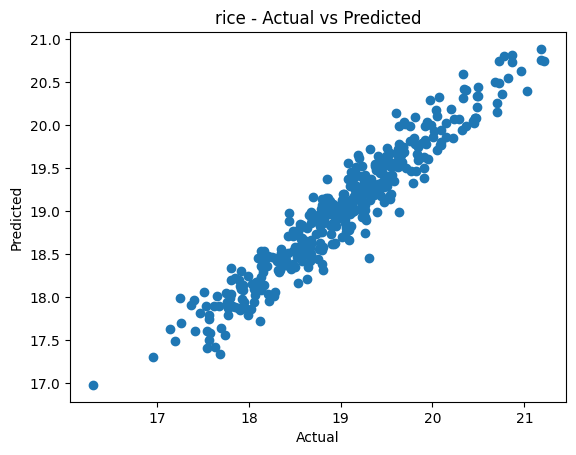

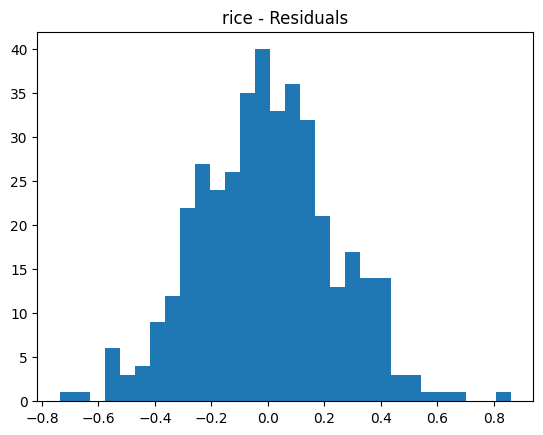


 Training for: wheat
Shape: (2000, 20)
R2: 0.8687, MAE: 0.218, RMSE: 0.273


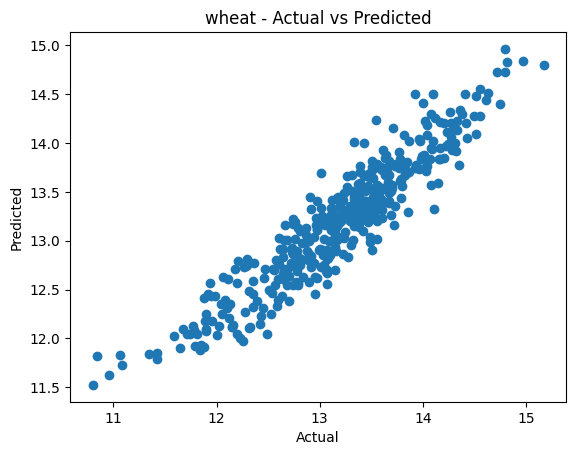

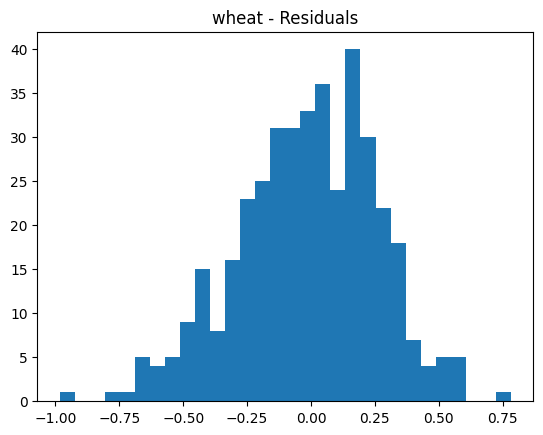


 Training for: cotton
Shape: (2000, 20)
R2: 0.8957, MAE: 0.211, RMSE: 0.263


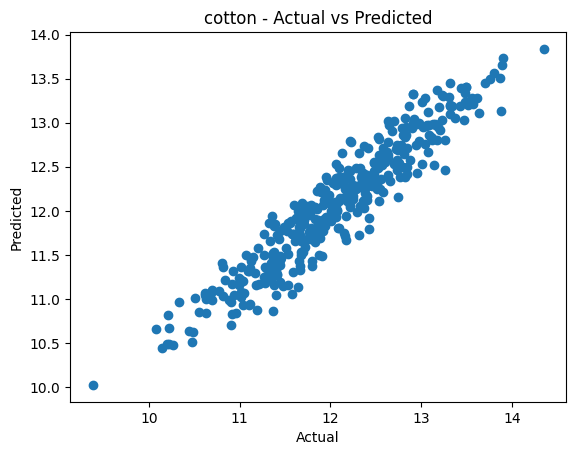

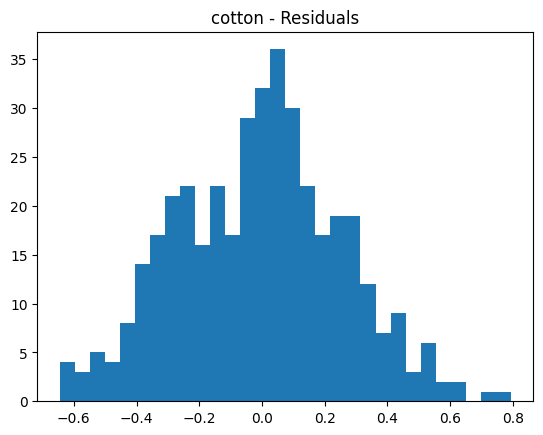


 Training for: sugarcane
Shape: (2000, 20)
R2: 0.9304, MAE: 0.205, RMSE: 0.266


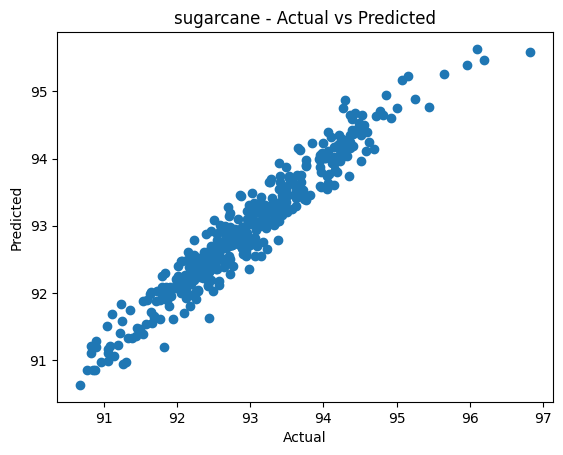

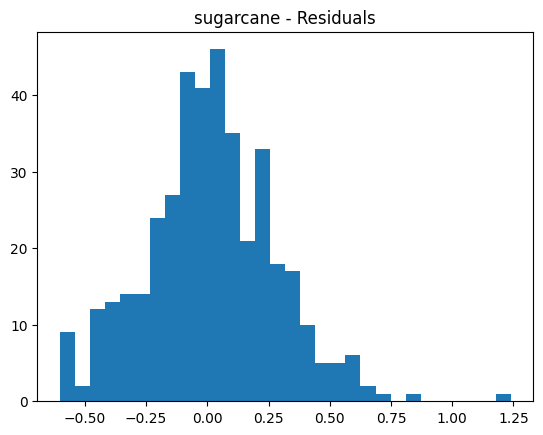


 Training for: maize
Shape: (2000, 20)
R2: 0.9106, MAE: 0.200, RMSE: 0.252


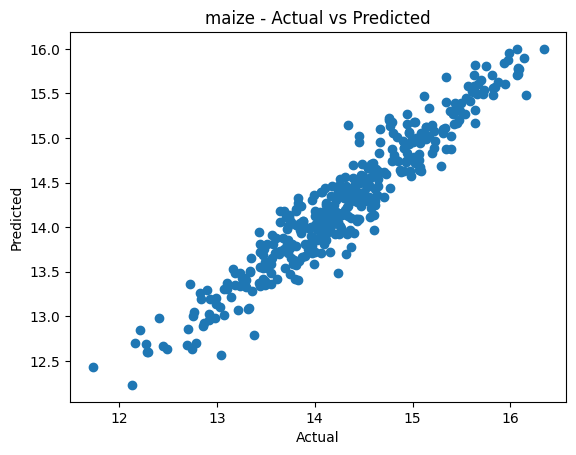

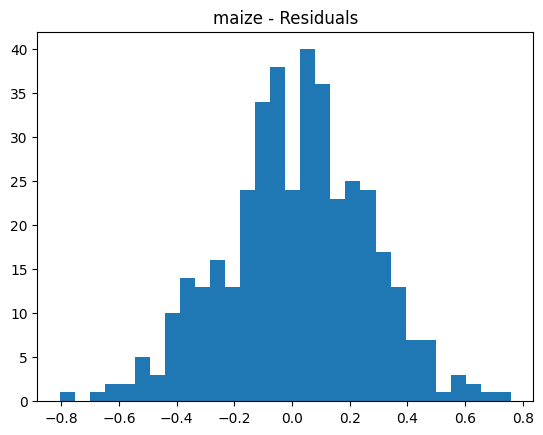

In [11]:
results = []

for crop in df["crop"].unique():
    
    crop_encoder = encoders["crop"]
    crop_name = crop_encoder.inverse_transform([crop])[0]
    
    print(f"\n Training for: {crop_name}")
    
    crop_df = df[df["crop"] == crop]
    
    print("Shape:", crop_df.shape)  # debug
    
 
    X = crop_df.drop(["yield_t_ha", "crop", "production"], axis=1)

    X["water_stress"] = X["total_rainfall"] * (1 - X["drought_index"])
    X["fertility_index"] = (
        X["soil_organic_carbon"] +
        X["fertilizer_n"]/100 +
        X["fertilizer_p"]/100 +
        X["fertilizer_k"]/100
    )
    X["ndvi_water"] = X["ndvi_mean"] * X["total_rainfall"]
    y = crop_df["yield_t_ha"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=35,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"R2: {r2:.4f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    
    results.append([crop_name, r2, mae, rmse])
    
    joblib.dump(model, f"models/{crop_name}_rf_model.pkl")
    
    # Scatter Plot
    plt.figure()
    plt.scatter(y_test, preds)
    plt.title(f"{crop_name} - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()
    
    #Residuals Plot
    plt.figure()
    plt.hist(y_test - preds, bins=30)
    plt.title(f"{crop_name} - Residuals")
    plt.show()
    

In [13]:
metrics_df = pd.DataFrame(results, columns=["Crop","R2","MAE","RMSE"])
metrics_df

,Crop,R2,MAE,RMSE
0,rice,0.917219,0.190429,0.240624
1,wheat,0.868742,0.217553,0.272948
2,cotton,0.895739,0.210985,0.262899
3,sugarcane,0.930422,0.204691,0.265670
4,maize,0.910593,0.200025,0.251695
